# Phase 3 (Exploratory Data Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PJME_data = pd.read_csv(
    "processed_data/PJME_phase2_preprocessed.csv",
    parse_dates=["Datetime"]
)

In [3]:
PJME_data = PJME_data.set_index("Datetime")

# Sort chronologically
PJME_data = PJME_data.sort_index()

print(PJME_data.shape)
print(PJME_data.head())

(145224, 15)
                     PJME_MW  Hour  Day  Week  Month  DayOfWeek  IsWeekend  \
Datetime                                                                     
2002-01-08 01:00:00  29445.0     1    8     2      1          1          0   
2002-01-08 02:00:00  28670.0     2    8     2      1          1          0   
2002-01-08 03:00:00  28375.0     3    8     2      1          1          0   
2002-01-08 04:00:00  28542.0     4    8     2      1          1          0   
2002-01-08 05:00:00  29261.0     5    8     2      1          1          0   

                       Lag_1   Lag_24   Lag_48  Lag_168  Rolling_Mean_24  \
Datetime                                                                   
2002-01-08 01:00:00  31187.0  26862.0  27100.0  30393.0     33452.583333   
2002-01-08 02:00:00  29445.0  25976.0  26097.0  29265.0     33560.208333   
2002-01-08 03:00:00  28670.0  25641.0  25793.0  28357.0     33672.458333   
2002-01-08 04:00:00  28375.0  25666.0  25657.0  27899.0     

### Overall Electrivity Demand

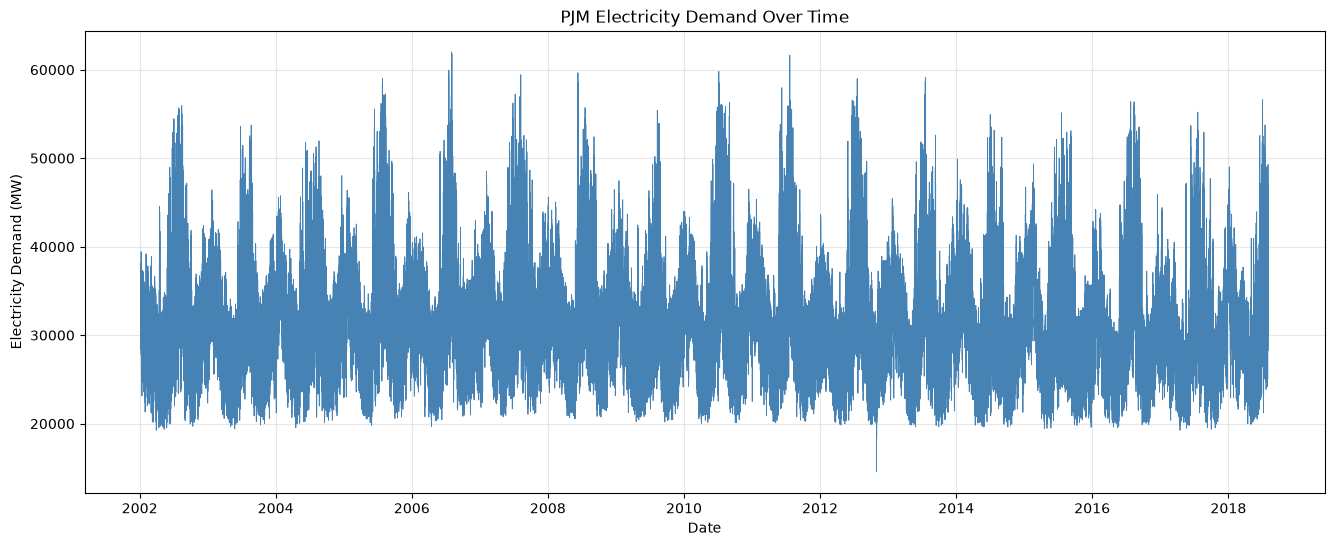

In [4]:
plt.figure(figsize=(16, 6))

plt.plot(
    PJME_data.index,
    PJME_data["PJME_MW"],
    color="steelblue",
    linewidth=0.6
)

plt.title("PJM Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_overall_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Zoom into one year

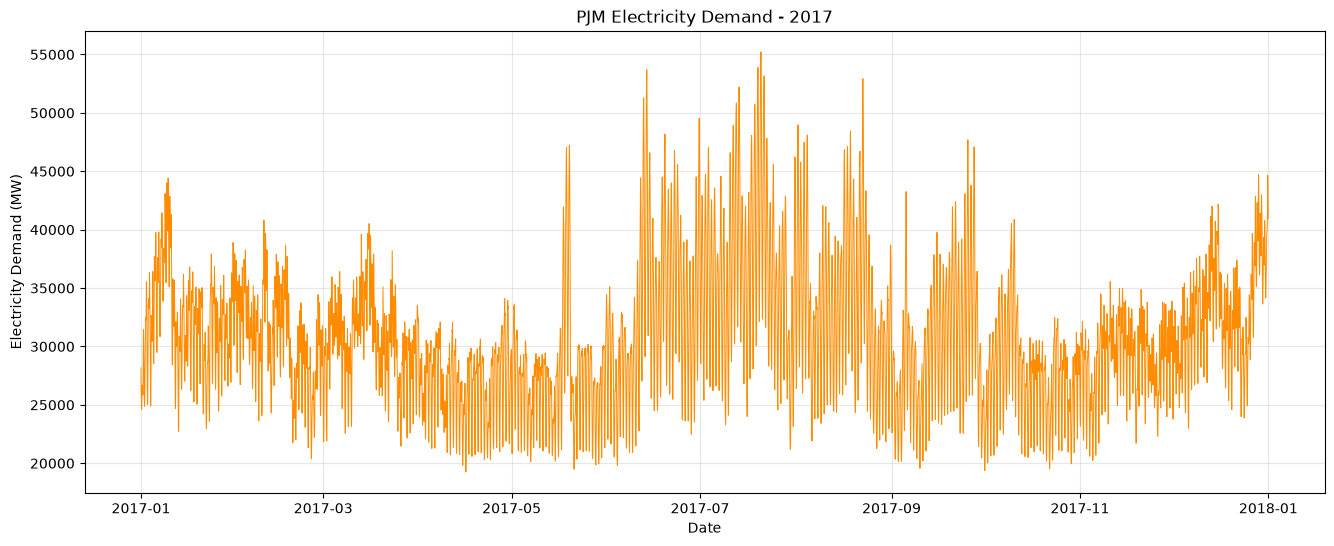

In [5]:
one_year = PJME_data.loc["2017"]

plt.figure(figsize=(16, 6))

plt.plot(
    one_year.index,
    one_year["PJME_MW"],
    color="darkorange",
    linewidth=0.7
)

plt.title("PJM Electricity Demand - 2017")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_demand_2017.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Average Hourly Demand

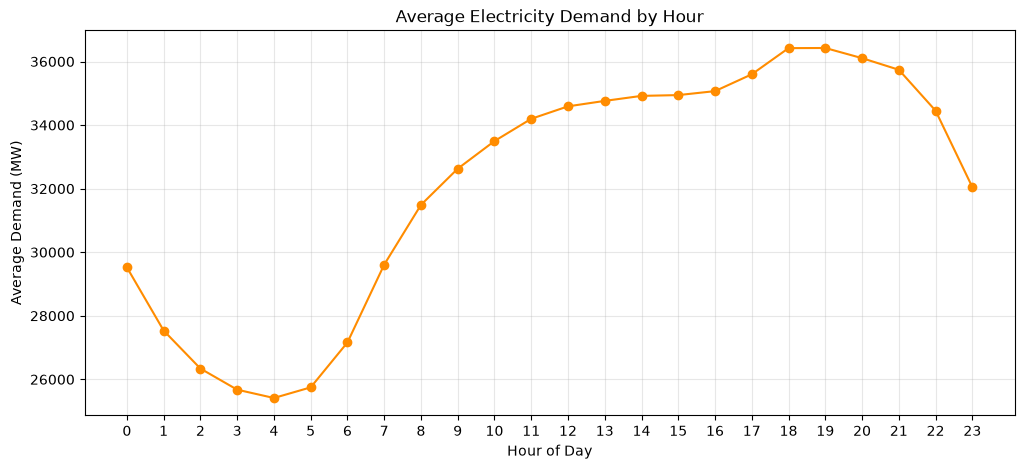

In [6]:
hourly_profile = PJME_data.groupby(
    "Hour"
)["PJME_MW"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o",
    color="darkorange"
)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_hourly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
print(hourly_profile)

Hour
0     29523.789126
1     27534.414312
2     26339.197488
3     25674.638242
4     25412.983309
5     25747.376632
6     27160.779706
7     29608.787969
8     31488.667493
9     32627.402743
10    33496.486696
11    34197.449017
12    34589.229714
13    34760.901008
14    34918.655759
15    34943.309701
16    35068.189886
17    35597.819699
18    36421.016196
19    36425.255495
20    36105.706330
21    35740.395307
22    34452.719385
23    32046.868121
Name: PJME_MW, dtype: float64


In [8]:
print("Peak hour:")
print(hourly_profile.idxmax())

print("\nLowest demand hour:")
print(hourly_profile.idxmin())

Peak hour:
19

Lowest demand hour:
4


### Average Demand by Day of Week

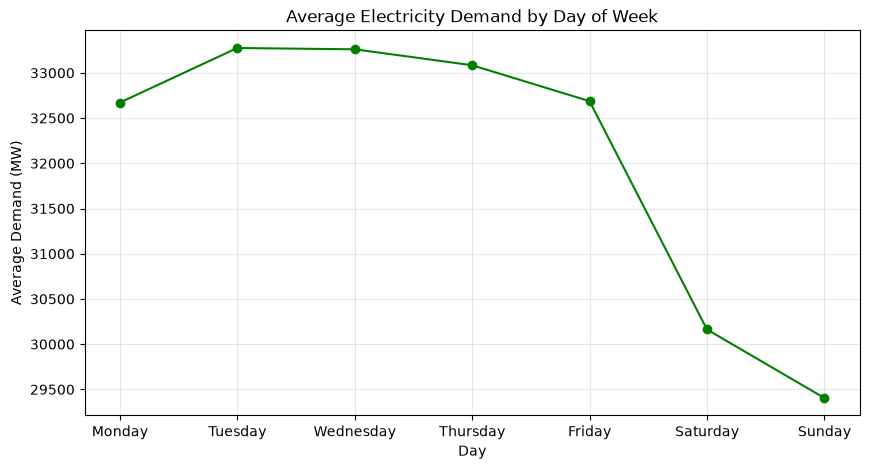

In [9]:
weekly_profile = PJME_data.groupby(
    "DayOfWeek"
)["PJME_MW"].mean()

days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.plot(
    days,
    weekly_profile.values,
    marker="o",
    color="green"
)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand (MW)")
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_weekly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print(weekly_profile)

DayOfWeek
0    32671.262442
1    33274.794306
2    33260.341378
3    33084.209152
4    32687.041665
5    30162.600212
6    29404.790557
Name: PJME_MW, dtype: float64


### Weekday vs Weekend

In [11]:
weekend_profile = PJME_data.groupby(
    "IsWeekend"
)["PJME_MW"].mean()

print(weekend_profile)

IsWeekend
0    32995.670493
1    29783.695385
Name: PJME_MW, dtype: float64


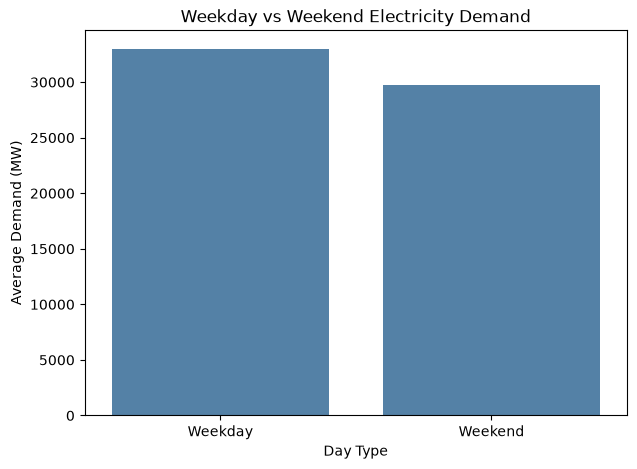

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=weekend_profile.values,
    color="steelblue"
)

plt.title("Weekday vs Weekend Electricity Demand")
plt.xlabel("Day Type")
plt.ylabel("Average Demand (MW)")

plt.savefig(
    "images/eda_weekday_weekend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Monthly Demand Distribution

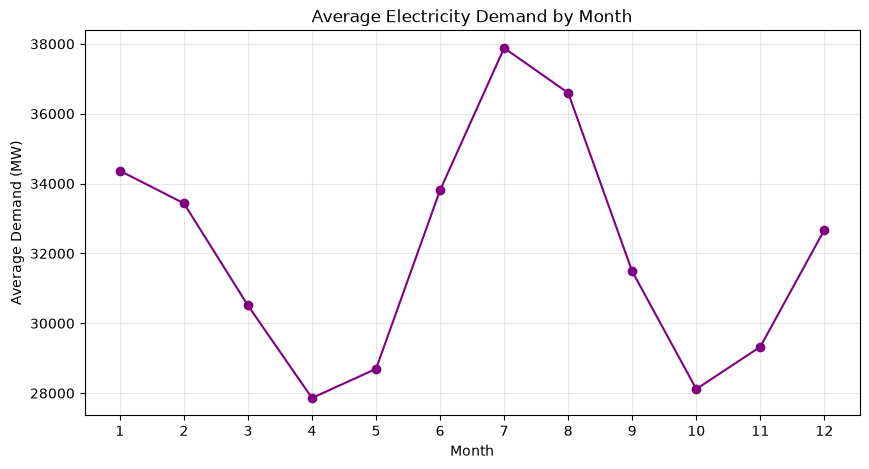

In [13]:
monthly_profile = PJME_data.groupby(
    "Month"
)["PJME_MW"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker="o",
    color="purple"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_monthly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
print(monthly_profile)

Month
1     34367.798702
2     33434.972049
3     30510.017868
4     27861.419036
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28117.006762
11    29327.696658
12    32676.480343
Name: PJME_MW, dtype: float64


### Hour vs day

In [15]:
hour_day = PJME_data.pivot_table(
    values="PJME_MW",
    index="Hour",
    columns="DayOfWeek",
    aggfunc="mean"
)

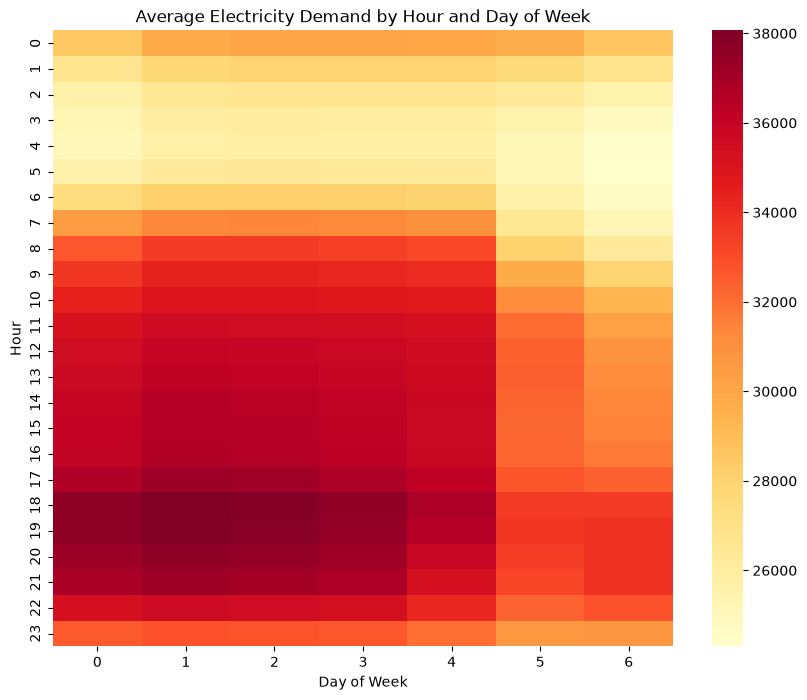

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    hour_day,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average Electricity Demand by Hour and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour")

plt.savefig(
    "images/eda_hour_day_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribution of Electricity Demand

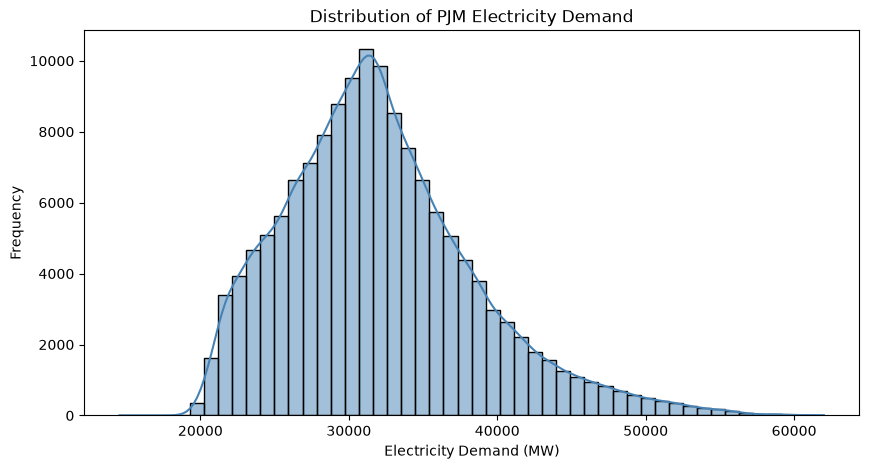

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    PJME_data["PJME_MW"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of PJM Electricity Demand")
plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")

plt.savefig(
    "images/eda_demand_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

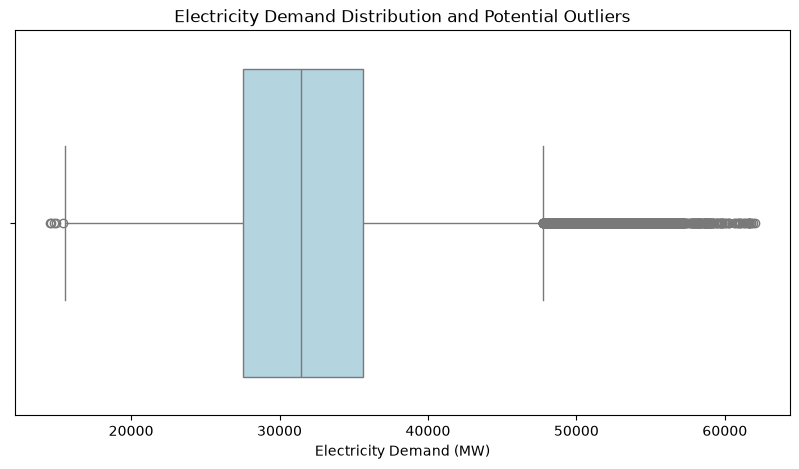

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=PJME_data["PJME_MW"],
    color="lightblue"
)

plt.title("Electricity Demand Distribution and Potential Outliers")
plt.xlabel("Electricity Demand (MW)")

plt.savefig(
    "images/eda_demand_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Rolling Mean and Standard Deviation

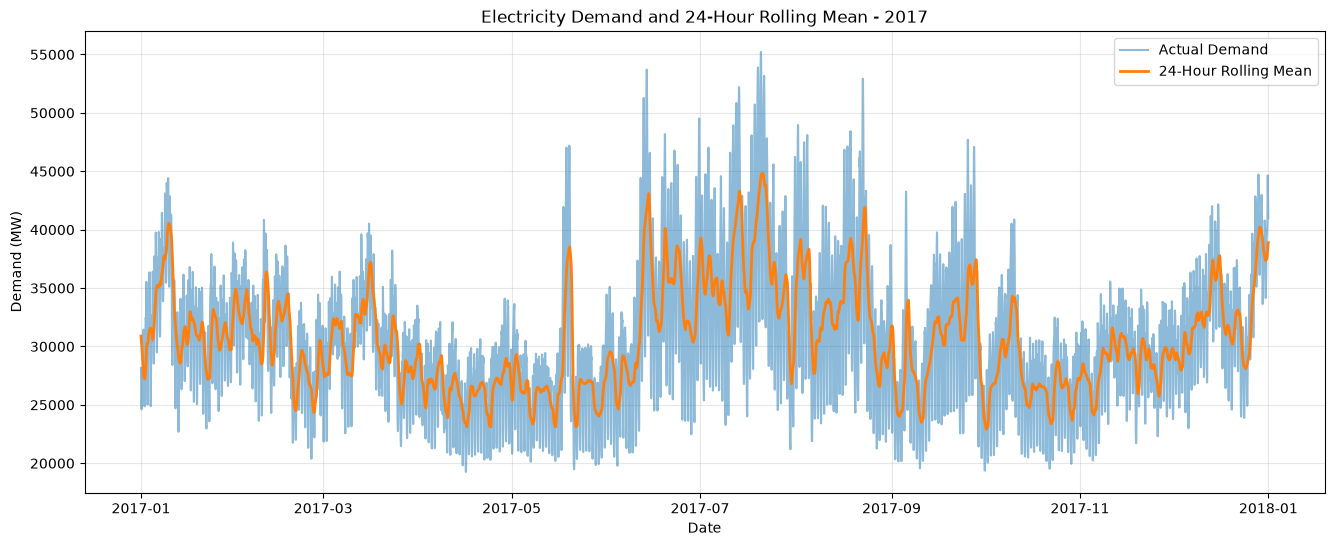

In [19]:
sample_data = PJME_data.loc["2017"].copy()

plt.figure(figsize=(16, 6))

plt.plot(
    sample_data.index,
    sample_data["PJME_MW"],
    label="Actual Demand",
    alpha=0.5
)

plt.plot(
    sample_data.index,
    sample_data["Rolling_Mean_24"],
    label="24-Hour Rolling Mean",
    linewidth=2
)

plt.title("Electricity Demand and 24-Hour Rolling Mean - 2017")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_rolling_mean_24.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

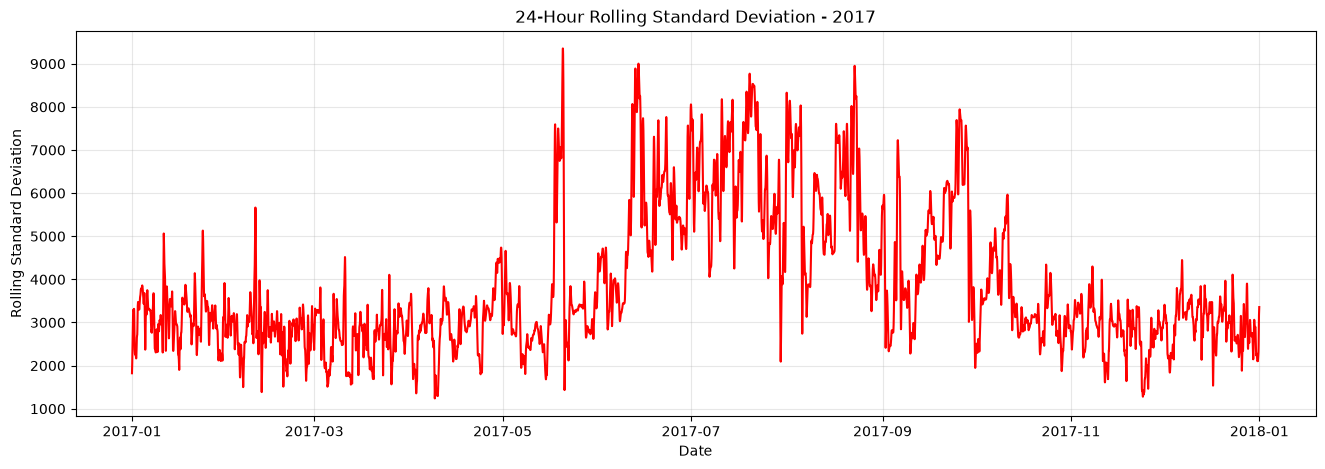

In [20]:
#sd
plt.figure(figsize=(16, 5))

plt.plot(
    sample_data.index,
    sample_data["Rolling_Std_24"],
    color="red"
)

plt.title("24-Hour Rolling Standard Deviation - 2017")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(alpha=0.3)

plt.savefig(
    "images/eda_rolling_std_24.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### lag relationship

In [21]:
print(
    "Correlation with Lag 1:",
    PJME_data["PJME_MW"].corr(PJME_data["Lag_1"])
)

print(
    "Correlation with Lag 24:",
    PJME_data["PJME_MW"].corr(PJME_data["Lag_24"])
)

print(
    "Correlation with Lag 48:",
    PJME_data["PJME_MW"].corr(PJME_data["Lag_48"])
)

print(
    "Correlation with Lag 168:",
    PJME_data["PJME_MW"].corr(PJME_data["Lag_168"])
)

Correlation with Lag 1: 0.9747932366425909
Correlation with Lag 24: 0.8914748516842779
Correlation with Lag 48: 0.7728528501585648
Correlation with Lag 168: 0.7824702046663033


### Correlation Heatmap

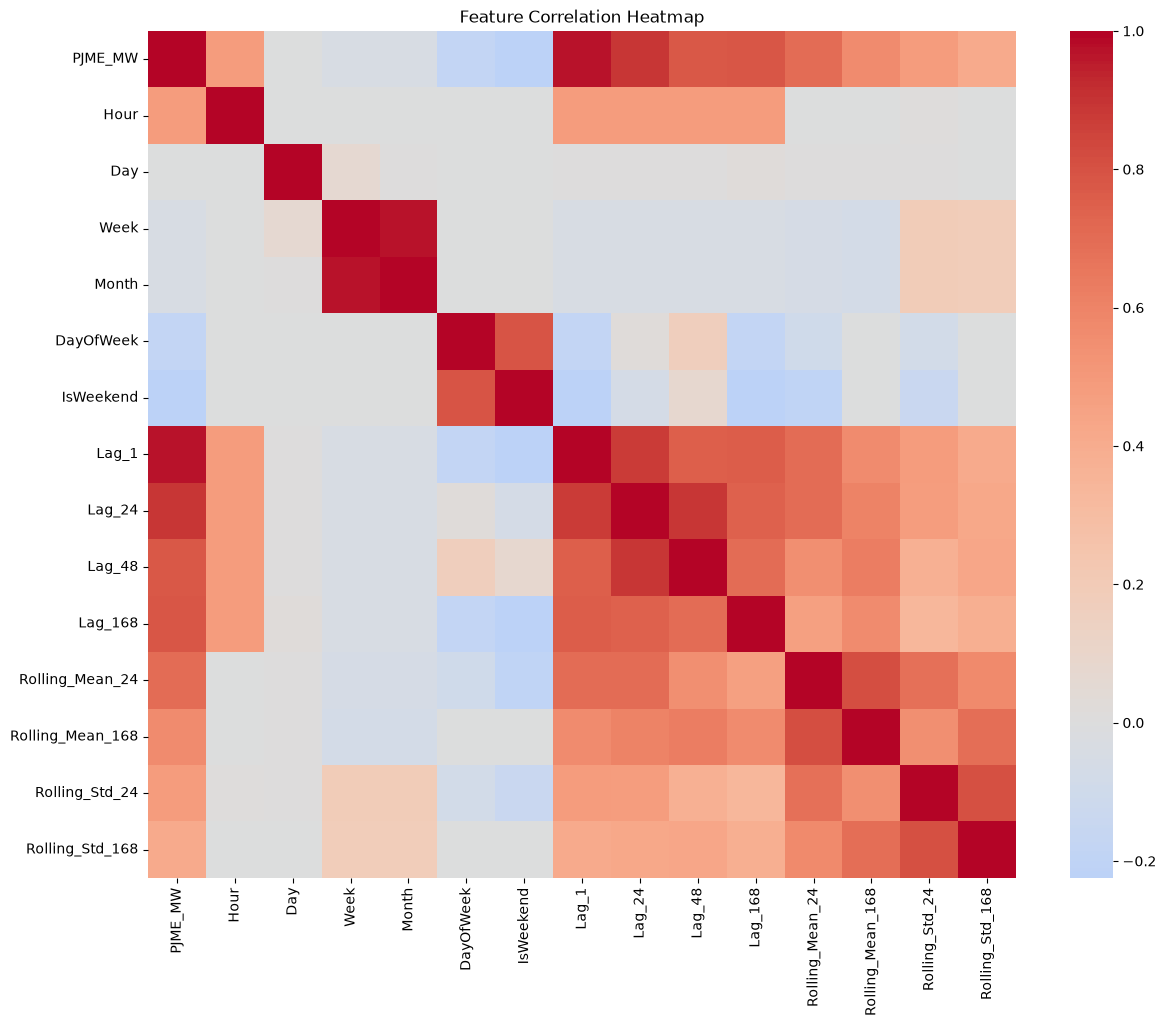

In [22]:
correlation = PJME_data[
    [
        "PJME_MW",
        "Hour",
        "Day",
        "Week",
        "Month",
        "DayOfWeek",
        "IsWeekend",
        "Lag_1",
        "Lag_24",
        "Lag_48",
        "Lag_168",
        "Rolling_Mean_24",
        "Rolling_Mean_168",
        "Rolling_Std_24",
        "Rolling_Std_168"
    ]
].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.savefig(
    "images/eda_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Auto Correlation

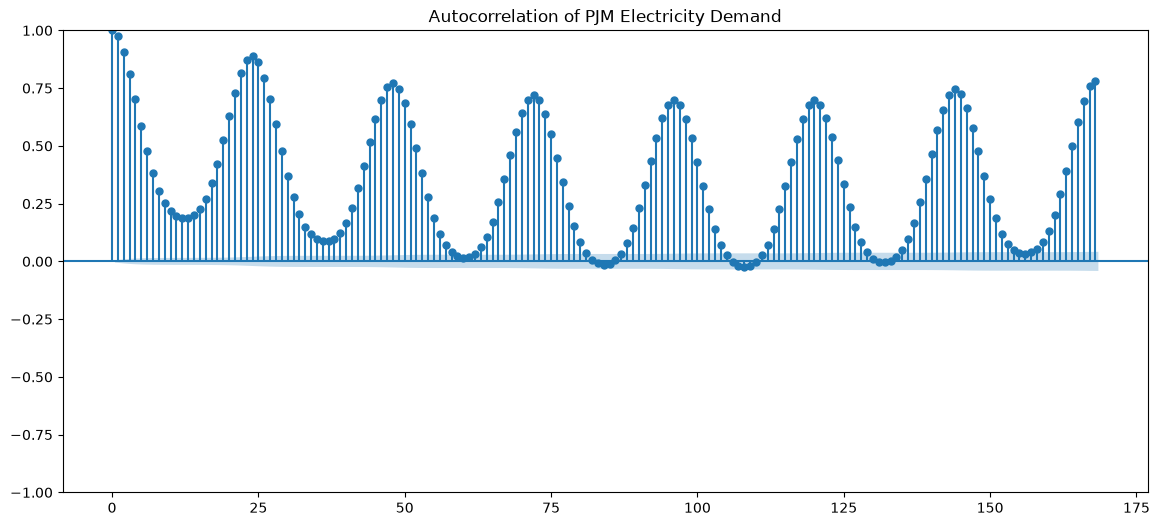

In [23]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))

plot_acf(
    PJME_data["PJME_MW"],
    lags=168,
    ax=plt.gca()
)

plt.title("Autocorrelation of PJM Electricity Demand")

plt.savefig(
    "images/eda_autocorrelation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Seasonal Decomposition

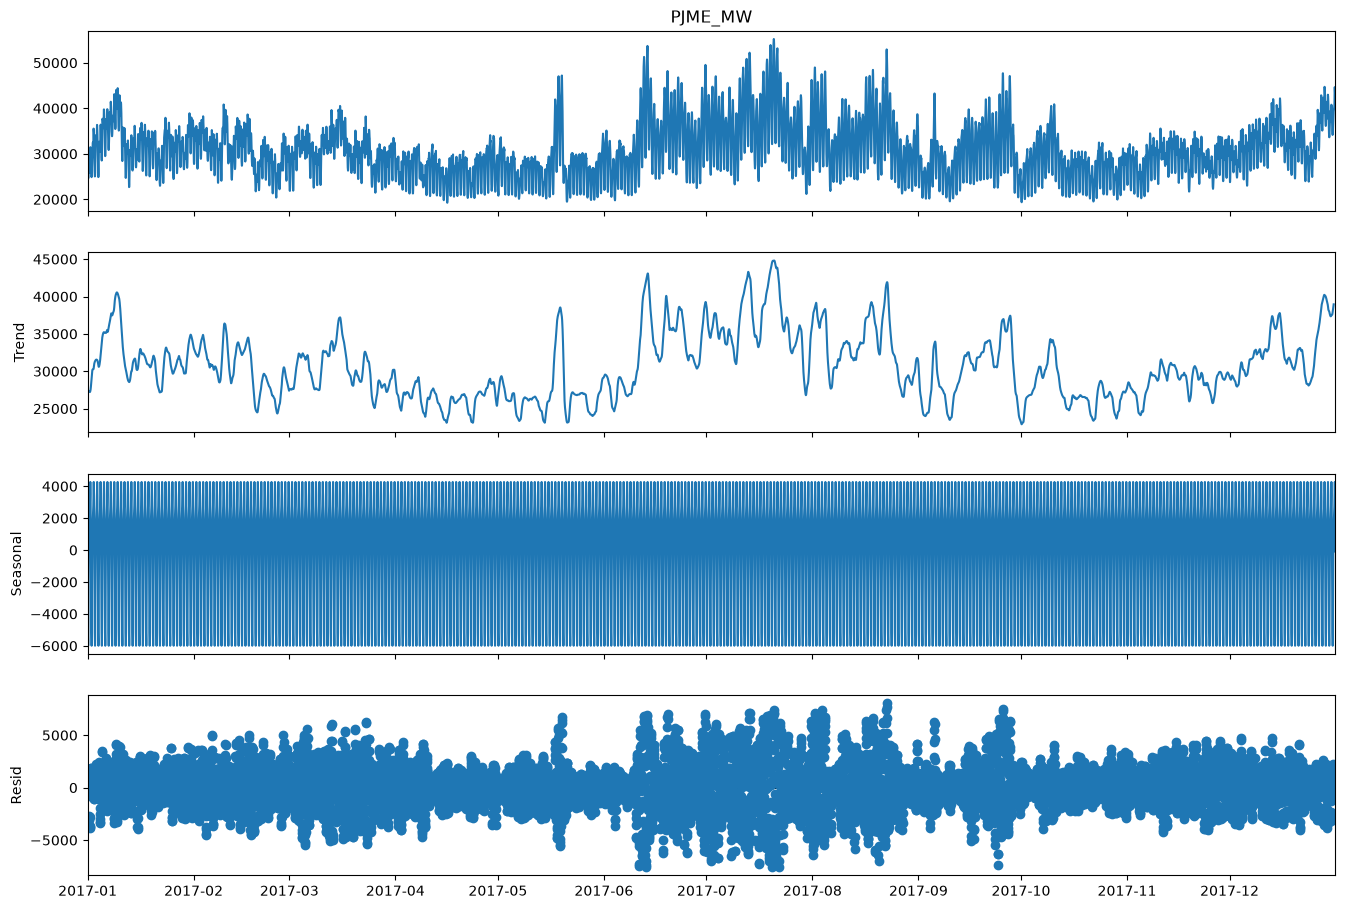

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use one year to make decomposition manageable
decomp_data = PJME_data["PJME_MW"].loc["2017"]

decomposition = seasonal_decompose(
    decomp_data,
    model="additive",
    period=24
)

fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.savefig(
    "images/eda_seasonal_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()